In [69]:
import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset,DataLoader
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [70]:
data=pd.read_csv(r"C:\Users\nishi\code\DL\Churn Modeling\Churn_Modelling.csv")
data.head()
data['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [71]:
enc=OrdinalEncoder()
Geography=['France', 'Spain', 'Germany']
Gender=['Female', 'Male']
data['Gender']=enc.fit_transform(data[['Gender']])
data['Geography']=enc.fit_transform(data[['Geography']])
X=data.drop(columns=['Exited','Surname']).values
y=data['Exited'].values

In [72]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.15,random_state=147)
X_train, X_val, y_train, y_val=train_test_split(X_train,y_train, test_size=0.06,random_state=247)

In [73]:
scaler_x=StandardScaler()
scaler_y=StandardScaler()
scaler_x.fit(X_train)
X_train = scaler_x.transform(X_train)
X_test  = scaler_x.transform(X_test)
X_val = scaler_x.transform(X_val)
X_train=torch.tensor(X_train,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_test=torch.tensor(y_test,dtype=torch.float32)
X_val=torch.tensor(X_val,dtype=torch.float32)
y_val=torch.tensor(y_val,dtype=torch.float32)
y_train

tensor([0., 0., 0.,  ..., 1., 0., 0.])

In [74]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
X_train=X_train.to(device)
y_train=y_train.to(device)
X_test=X_test.to(device)
y_test=y_test.to(device)
X_val=X_val.to(device)
y_val=y_val.to(device)

In [75]:
train_loader=DataLoader(TensorDataset(X_train,y_train),batch_size=64,shuffle=True)
test_loader=DataLoader(TensorDataset(X_test,y_test),batch_size=32)
val_loader=DataLoader(TensorDataset(X_val,y_val),batch_size=64)

In [ ]:
class perceptron(torch.nn.Module):
    def __init__(self, num_features, num_classes, num_hidden_1, num_hidden_2):
        super().__init__()
        self.my_network=torch.nn.Sequential(

            torch.nn.Flatten(),
            torch.nn.Linear(num_features, num_hidden_1),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.BatchNorm1d(num_hidden_1),

            torch.nn.Linear(num_hidden_1, num_hidden_2),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(num_hidden_2),

            torch.nn.Linear(num_hidden_2,num_classes)
        )
    def forward(self,x):
        logits=self.my_network(x)
        return logits

In [77]:
def eval(model,device,data):
    model.eval()
    with torch.no_grad():
        correct_pred,num_examples=0,0
        loss_list=[]
        for i,(features,targets) in enumerate(data):
            features=features.to(device)
            targets=targets.to(device).long()

            logits=model(features)
            loss = F.cross_entropy(logits, targets)
            _,predicted_labels=torch.max(logits,dim=1)
            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()

            loss_list.append(loss.item())
    return correct_pred.float()/num_examples * 100,torch.tensor(loss_list).mean().item()
def train(model,train_data,val_data,num_epochs,optimizer,device,scheduler):
    minibatch_loss,train_acc_list,val_acc_list=[],[],[]
    start_time=time.time()
    for epoch in range(num_epochs):
        model.train()

        for batch_idx , (features,targets) in enumerate (train_data):
            features=features.to(device)
            targets=targets.to(device).long()

            logits=model(features)
            
            loss = F.cross_entropy(logits, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            minibatch_loss.append(loss.item())

            if not batch_idx % 25:
                print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
                      f'| Batch {batch_idx:04d}/{len(train_data):04d} '
                      f'| Loss: {loss.item():.4f}')
                
        model.eval()
        with torch.no_grad():
            train_acc,_=eval(model,device=device,data=train_data)
            val_acc,val_loss=eval(model,device=device,data=val_data)
            print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
                  f'| Train: {train_acc :.2f}% '
                  f'| Val: {val_acc :.2f}% ')
            train_acc_list.append(train_acc.item())
            val_acc_list.append(val_acc.item())
            scheduler.step(val_acc)
        elapsed_time=time.time() - start_time
        avg_loss=torch.tensor(minibatch_loss).mean().item()
        print(f'avg loss: {avg_loss}\n time:{elapsed_time}')
    return minibatch_loss,train_acc_list,val_acc_list


In [82]:
model=perceptron(num_features=X_train.shape[1],
                 num_classes=2,num_hidden_1=128,
                 num_hidden_2=256)
model=model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
scheduler = ReduceLROnPlateau(optimizer, "min", factor=0.95, patience=5)
minibatch_loss,train_acc_list,val_acc_list=train(model,train_data=train_loader,
                                    val_data=val_loader,num_epochs=200,
                                    optimizer=optimizer,device=device,
                                    scheduler=scheduler)

Epoch: 001/200 | Batch 0000/0125 | Loss: 0.6721
Epoch: 001/200 | Batch 0025/0125 | Loss: 0.5289
Epoch: 001/200 | Batch 0050/0125 | Loss: 0.4012
Epoch: 001/200 | Batch 0075/0125 | Loss: 0.5568
Epoch: 001/200 | Batch 0100/0125 | Loss: 0.3840
Epoch: 001/200 | Train: 85.17% | Val: 85.88% 
avg loss: 0.4475351870059967
 time:0.8172826766967773
Epoch: 002/200 | Batch 0000/0125 | Loss: 0.4158
Epoch: 002/200 | Batch 0025/0125 | Loss: 0.3209
Epoch: 002/200 | Batch 0050/0125 | Loss: 0.4431
Epoch: 002/200 | Batch 0075/0125 | Loss: 0.4716
Epoch: 002/200 | Batch 0100/0125 | Loss: 0.4639
Epoch: 002/200 | Train: 85.16% | Val: 85.69% 
avg loss: 0.415749728679657
 time:1.6528711318969727
Epoch: 003/200 | Batch 0000/0125 | Loss: 0.3461
Epoch: 003/200 | Batch 0025/0125 | Loss: 0.3154
Epoch: 003/200 | Batch 0050/0125 | Loss: 0.4489
Epoch: 003/200 | Batch 0075/0125 | Loss: 0.3112
Epoch: 003/200 | Batch 0100/0125 | Loss: 0.4255
Epoch: 003/200 | Train: 85.67% | Val: 86.08% 
avg loss: 0.40323808789253235
 time

C:\Users\nishi\AppData\Local\Temp\ipykernel_26796\65627979.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


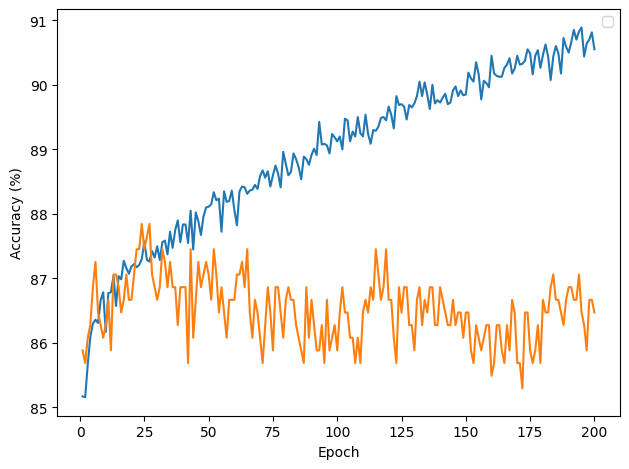

In [83]:
plt.plot(range(1, len(train_acc_list)+1), train_acc_list)
plt.plot(range(1, len(val_acc_list)+1), val_acc_list)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()


In [84]:
test_acc=eval(model,device=device,data=test_loader)
test_acc

(tensor(85.4667, device='cuda:0'), 0.3645786941051483)